# Proyecto de A/B Testing en Marketing
**Analítica de Producto / Marketing**

## 1. El Problema de Negocio
Hemos enviado dos versiones de una campaña (o Landing Page):
- **Variante A (Control):** Diseño tradicional.
- **Variante B (Tratamiento):** Diseño con un nuevo botón de llamada a la acción (CTA) y mensaje de urgencia.

**Misión:** Limpiar los datos, calcular las tasas de conversión y realizar un Test de Hipótesis para confirmar si la Variante B fue matemáticamente mejor o si la diferencia fue por puro azar.


In [4]:
%pip install pandas numpy seaborn matplotlib scipy statsmodels


Note: you may need to restart the kernel to use updated packages.


c:\Users\yrami\AppData\Local\Programs\Python\Python311\python.exe: No module named pip


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.stats.api as sms

# Configuración de estilos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


## 2. Carga y Visión General de Datos Sucios

In [2]:
df_raw = pd.read_csv('raw_leads.csv')
print(f"Total de registros iniciales: {len(df_raw)}")

display(df_raw.head())
display(df_raw.info())
display(df_raw['variante'].value_counts())


Total de registros iniciales: 5100


,lead_id,timestamp,variante,dispositivo,fuente,conversion
0,092c5093-96c7-4dae-87af-b2e9505f254a,2026-03-23 16:44:17,A,desktop,paid_search,0
1,6f500362-0751-4dcd-ae3f-3fc8e06fce6d,2026-03-23 02:17:03,B,desktop,organic,0
2,d2cf44fc-65f0-416b-80eb-26516ea5dffa,2026-04-01 16:53:33,B,desktop,social_media,1
3,562e6d30-e40b-4979-82d0-b308c7d1e3be,2026-03-07 20:23:42,B,mobile,social_media,0
4,baae3fa5-c060-4dab-8489-df97ffcdef73,2026-03-25 06:19:44,A,tablet,email,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   lead_id      5100 non-null   object
 1   timestamp    5100 non-null   object
 2   variante     5100 non-null   object
 3   dispositivo  4947 non-null   object
 4   fuente       5100 non-null   object
 5   conversion   5100 non-null   int64 
dtypes: int64(1), object(5)
memory usage: 239.2+ KB


None

variante
B        2561
A        2488
C          23
test       15
A_old      13
Name: count, dtype: int64

## 3. Limpieza de Datos (Data Cleaning)
Encontramos múltiples errores intencionales (o del mundo real) en nuestra tubería, tales como:
- Duplicados
- Registros con variantes inválidas
- Fechas extremas
- Valores nulos


In [3]:
df_clean = df_raw.copy()

# 1. Eliminar duplicados
df_clean = df_clean.drop_duplicates(subset=['lead_id'], keep='first')

# 2. Filtrar solo variantes válidas (A y B)
df_clean = df_clean[df_clean['variante'].isin(['A', 'B'])]

# 3. Remover fechas fuera de rango razonable (ej. año 1999 o > 2030)
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
df_clean = df_clean[(df_clean['timestamp'].dt.year >= 2020) & (df_clean['timestamp'].dt.year <= 2030)]

# 4. Manejar nulos (Vamos a rellenar dispositivo nulo con 'unknown')
df_clean['dispositivo'] = df_clean['dispositivo'].fillna('unknown')

print(f"Total de registros después de limpieza: {len(df_clean)}")
display(df_clean['variante'].value_counts())


Total de registros después de limpieza: 4899


variante
B    2475
A    2424
Name: count, dtype: int64

## 4. Análisis Exploratorio (EDA) y Tasas de Conversión

,Variante,Conversion Rate (%)
0,A,8.250825
1,B,11.151515


C:\Users\yrami\AppData\Local\Temp\ipykernel_27312\3580254202.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Variante', y='Conversion Rate (%)', data=conversion_rates, palette='viridis')


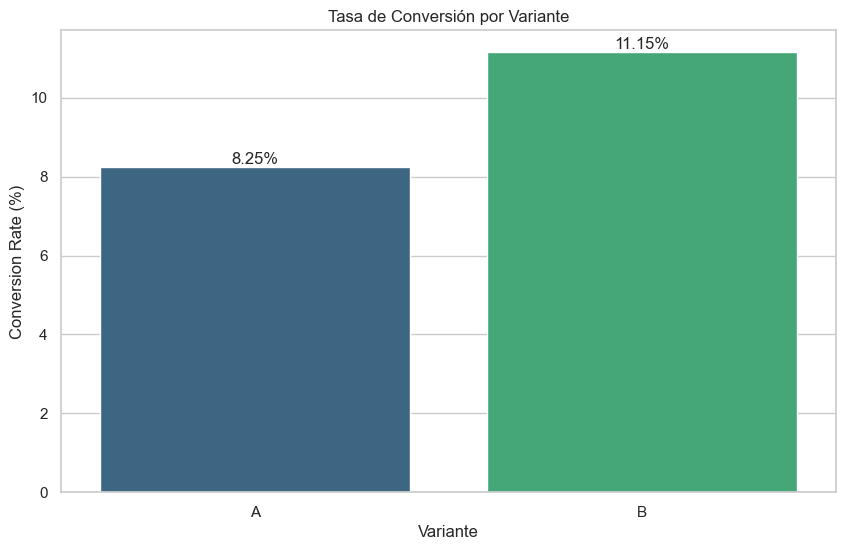

variante,A,B
dispositivo,,
desktop,9.049774,12.046444
mobile,7.768362,10.611148
tablet,9.737828,13.157895
unknown,5.128205,7.246377


In [4]:
# Tasa de conversión global por variante
conversion_rates = df_clean.groupby('variante')['conversion'].mean().reset_index()
conversion_rates['conversion'] = conversion_rates['conversion'] * 100
conversion_rates.columns = ['Variante', 'Conversion Rate (%)']

display(conversion_rates)

# Visualización
ax = sns.barplot(x='Variante', y='Conversion Rate (%)', data=conversion_rates, palette='viridis')
ax.set_title('Tasa de Conversión por Variante')
for i in ax.containers:
    ax.bar_label(i, fmt='%.2f%%')
plt.show()

# Conversión por dispositivo
conv_device = df_clean.groupby(['dispositivo', 'variante'])['conversion'].mean().unstack() * 100
display(conv_device)


## 5. Test de Hipótesis (A/B Testing)
Usaremos la aproximación para proporciones grandes (Z-Test) o bien Chi-cuadrado. Planteamos:
- **Hipótesis Nula (H0):** La tasa de conversión de B es menor o igual a A.
- **Hipótesis Alternativa (H1):** La tasa de conversión de B es mayor que A.

Fijaremos nuestro nivel de significancia (alfa) en 0.05.


In [5]:
# Separar los grupos
control_results = df_clean[df_clean['variante'] == 'A']['conversion']
treatment_results = df_clean[df_clean['variante'] == 'B']['conversion']

n_con = control_results.count()
n_treat = treatment_results.count()
successes = [control_results.sum(), treatment_results.sum()]
nobs = [n_con, n_treat]

# Test de proporciones (Z-Test)
from statsmodels.stats.proportion import proportions_ztest

z_stat, pval = proportions_ztest(successes, nobs=nobs)

print(f'Estadístico Z: {z_stat:.4f}')
print(f'p-Value: {pval:.4f}')

alpha = 0.05
if pval < alpha:
    print("\nConclusión: Rechazamos la hipótesis nula. La Variante B ha logrado una mejora ESTADÍSTICAMENTE SIGNIFICATIVA en la tasa de conversión.")
else:
    print("\nConclusión: No rechazamos la hipótesis nula. No hay suficiente evidencia para afirmar que B es mejor que A (la diferencia podría ser azar).")


Estadístico Z: -3.4273
p-Value: 0.0006

Conclusión: Rechazamos la hipótesis nula. La Variante B ha logrado una mejora ESTADÍSTICAMENTE SIGNIFICATIVA en la tasa de conversión.
